## Import packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Data Loading

Tiga dataset dari klien:

* client_data.csv: data pelanggan (konsumsi, tanggal kontrak, margin, dll.)
* price_data.csv: data harga historis (variable & fixed price per periode)
* Kolom churn di client_data.csv adalah target variable-nya.

In [25]:
client_df = pd.read_csv('/content/drive/MyDrive/Forage/Data Science - BCG /client_data (1).csv')
price_df = pd.read_csv('/content/drive/MyDrive/Forage/Data Science - BCG /price_data (1).csv')

print("client_df shape:", client_df.shape)
print("price_df shape:", price_df.shape)

client_df shape: (14606, 26)
price_df shape: (193002, 8)


You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [10]:
# Melihat 5 data teratas
client_df.head(5)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [11]:
price_df.head(5)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

Perhatikan kolom-kolom bertipe tanggal (*date_activ, date_end, date_modif_prod, date_renewal, price_date*) yang masih terbaca sebagai object/string, ini perlu dikonversi ke tipe datetime agar bisa dianalisis secara temporal.

In [12]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [13]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [26]:
# Konversi kolom tanggal ke datetime
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col])

price_df['price_date'] = pd.to_datetime(price_df['price_date'])

print("Konversi selesai.")
client_df[date_cols].dtypes

Konversi selesai.


,0
date_activ,datetime64[ns]
date_end,datetime64[ns]
date_modif_prod,datetime64[ns]
date_renewal,datetime64[ns]


In [28]:
# Cek missing values
print("Missing values - client_df:")
print(client_df.isnull().sum()[client_df.isnull().sum() > 0])
print()

print("Missing values - price_df:")
print(price_df.isnull().sum()[price_df.isnull().sum() > 0])

Missing values - client_df:
Series([], dtype: int64)

Missing values - price_df:
Series([], dtype: int64)


**Notes!**

Tidak ada nilai NaN eksplisit, tetapi ada beberapa kolom kategorikal (channel_sales, origin_up) memiliki nilai literal "MISSING" yang perlu diperlakukan sebagai data hilang saat dilakukan encoding/modeling nanti.

In [19]:
# melihat data duplicate pada `client_data.csv`
client_df.duplicated().sum()

np.int64(0)

In [20]:
# melihat data duplicate pada `price_data.csv`
price_df.duplicated().sum()

np.int64(0)

### Statistics Descriptive

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [31]:
client_df.describe().T

,count,mean,min,25%,50%,75%,max,std
cons_12m,14606.0,159220.286252,0.0,5674.75,14115.5,40763.75,6207104.0,573465.264198
cons_gas_12m,14606.0,28092.375325,0.0,0.0,0.0,0.0,4154590.0,162973.059057
cons_last_month,14606.0,16090.269752,0.0,0.0,792.5,3383.0,771203.0,64364.196422
date_activ,14606,2011-01-28 07:54:18.879912448,2003-05-09 00:00:00,2010-01-15 00:00:00,2011-03-04 00:00:00,2012-04-19 00:00:00,2014-09-01 00:00:00,NaN
date_end,14606,2016-07-27 20:48:26.422018560,2016-01-28 00:00:00,2016-04-27 06:00:00,2016-08-01 00:00:00,2016-10-31 00:00:00,2017-06-13 00:00:00,NaN
date_modif_prod,14606,2013-01-02 12:29:10.951663872,2003-05-09 00:00:00,2010-08-12 00:00:00,2013-06-19 00:00:00,2015-06-16 00:00:00,2016-01-29 00:00:00,NaN
date_renewal,14606,2015-07-21 06:59:00.353279488,2013-06-26 00:00:00,2015-04-17 00:00:00,2015-07-27 00:00:00,2015-10-29 00:00:00,2016-01-28 00:00:00,NaN
forecast_cons_12m,14606.0,1868.61488,0.0,494.995,1112.875,2401.79,82902.83,2387.571531
forecast_cons_year,14606.0,1399.762906,0.0,0.0,314.0,1745.75,175375.0,3247.786255
forecast_discount_energy,14606.0,0.966726,0.0,0.0,0.0,0.0,30.0,5.108289


In [32]:
price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_date,193002,2015-06-16 12:50:49.933161216,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.0,0.141027,0.0,0.125976,0.146033,0.151635,0.2807,0.025032
price_peak_var,193002.0,0.05463,0.0,0.0,0.085483,0.101673,0.229788,0.049924
price_mid_peak_var,193002.0,0.030496,0.0,0.0,0.0,0.072558,0.114102,0.036298
price_off_peak_fix,193002.0,43.334477,0.0,40.728885,44.26693,44.44471,59.44471,5.410297
price_peak_fix,193002.0,10.622875,0.0,0.0,0.0,24.339581,36.490692,12.841895
price_mid_peak_fix,193002.0,6.409984,0.0,0.0,0.0,16.226389,17.458221,7.773592


In [33]:
# Jumlah nilai unik per kolom - membantu identifikasi kolom kategorikal/konstan
client_df.nunique().sort_values()

,0
churn,2
has_gas,2
origin_up,6
channel_sales,8
nb_prod_act,10
forecast_discount_energy,12
num_years_antig,13
forecast_price_pow_off_peak,41
forecast_price_energy_peak,329
date_end,368


---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations.

### Stacked bar (Diagram Batang)

In [22]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

The first function `plot_stacked_bars` is used to plot a stacked bar chart. An example of how you could use this is shown below:

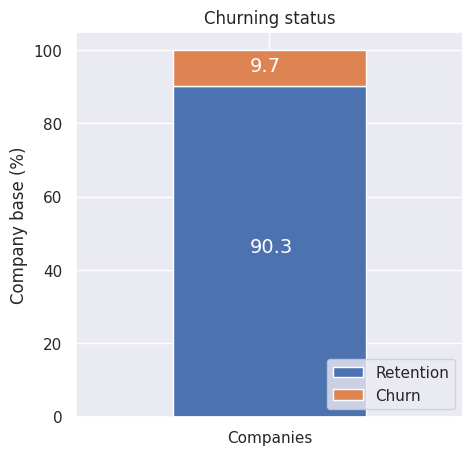

       Companies
churn           
0      90.284814
1       9.715186


In [34]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")
print(churn_percentage)

**Insight:**

Hanya sekitar 9.7% pelanggan yang churn, sedangkan 90.3% bertahan. Ini adalah dataset yang imbalanced, sangat penting untuk diperhatikan ketika membangun model prediktif nanti (misalnya perlu teknik seperti class weighting, SMOTE, atau metrik evaluasi selain accuracy).

The second function `annotate_bars` is used by the first function, but the third function `plot_distribution` helps you to plot the distribution of a numeric column. An example of how it can be used is given below:

### Distribusi konsumsi energi (retensi vs churn)

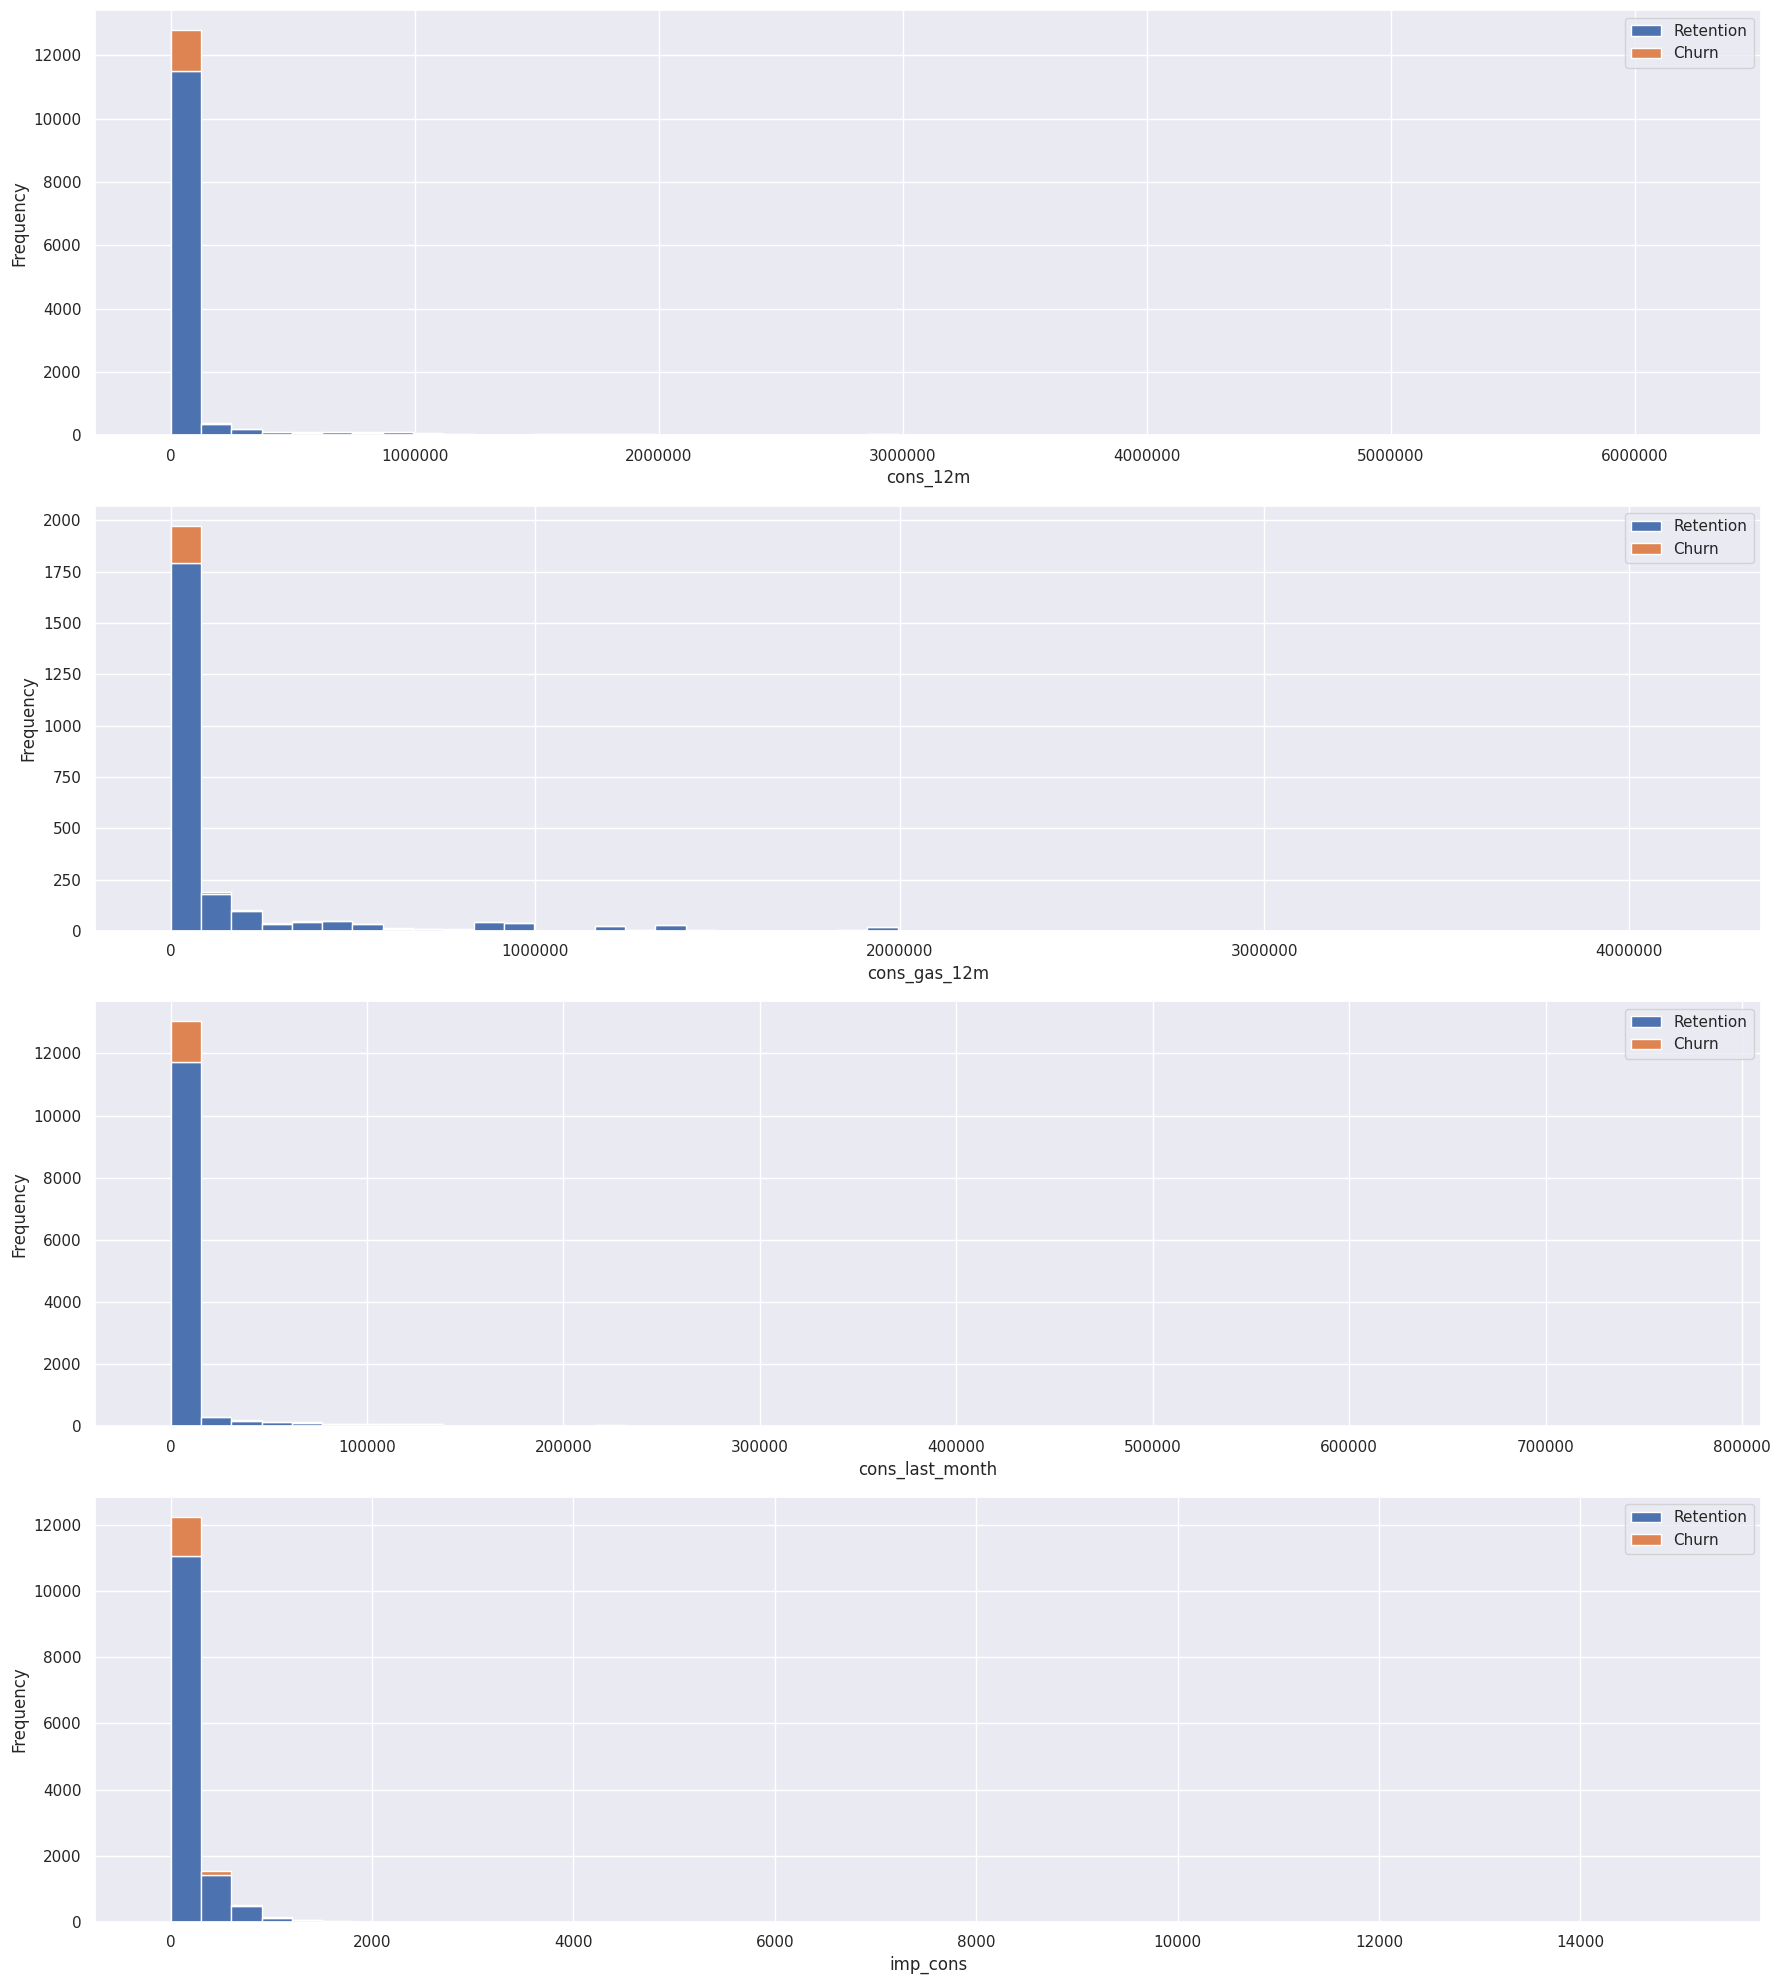

In [35]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=4, figsize=(18, 20))
plot_distribution(consumption, 'cons_12m', axs[0])
plot_distribution(consumption[consumption['has_gas'] == 't'], 'cons_gas_12m', axs[1])
plot_distribution(consumption, 'cons_last_month', axs[2])
plot_distribution(consumption, 'imp_cons', axs[3])
plt.tight_layout()
plt.show()

**Insight:**

Distribusi konsumsi sangat right-skewed (sebagian besar pelanggan memiliki konsumsi rendah, sedikit yang sangat tinggi) untuk keempat variabel ini. Pola churn terlihat tersebar merata di seluruh rentang konsumsi, yaitu tidak terdapat indikasi kuat bahwa pelanggan dengan konsumsi tertentu jauh lebih rentan churn.

### Distribusi margin & kekuatan berlangganan

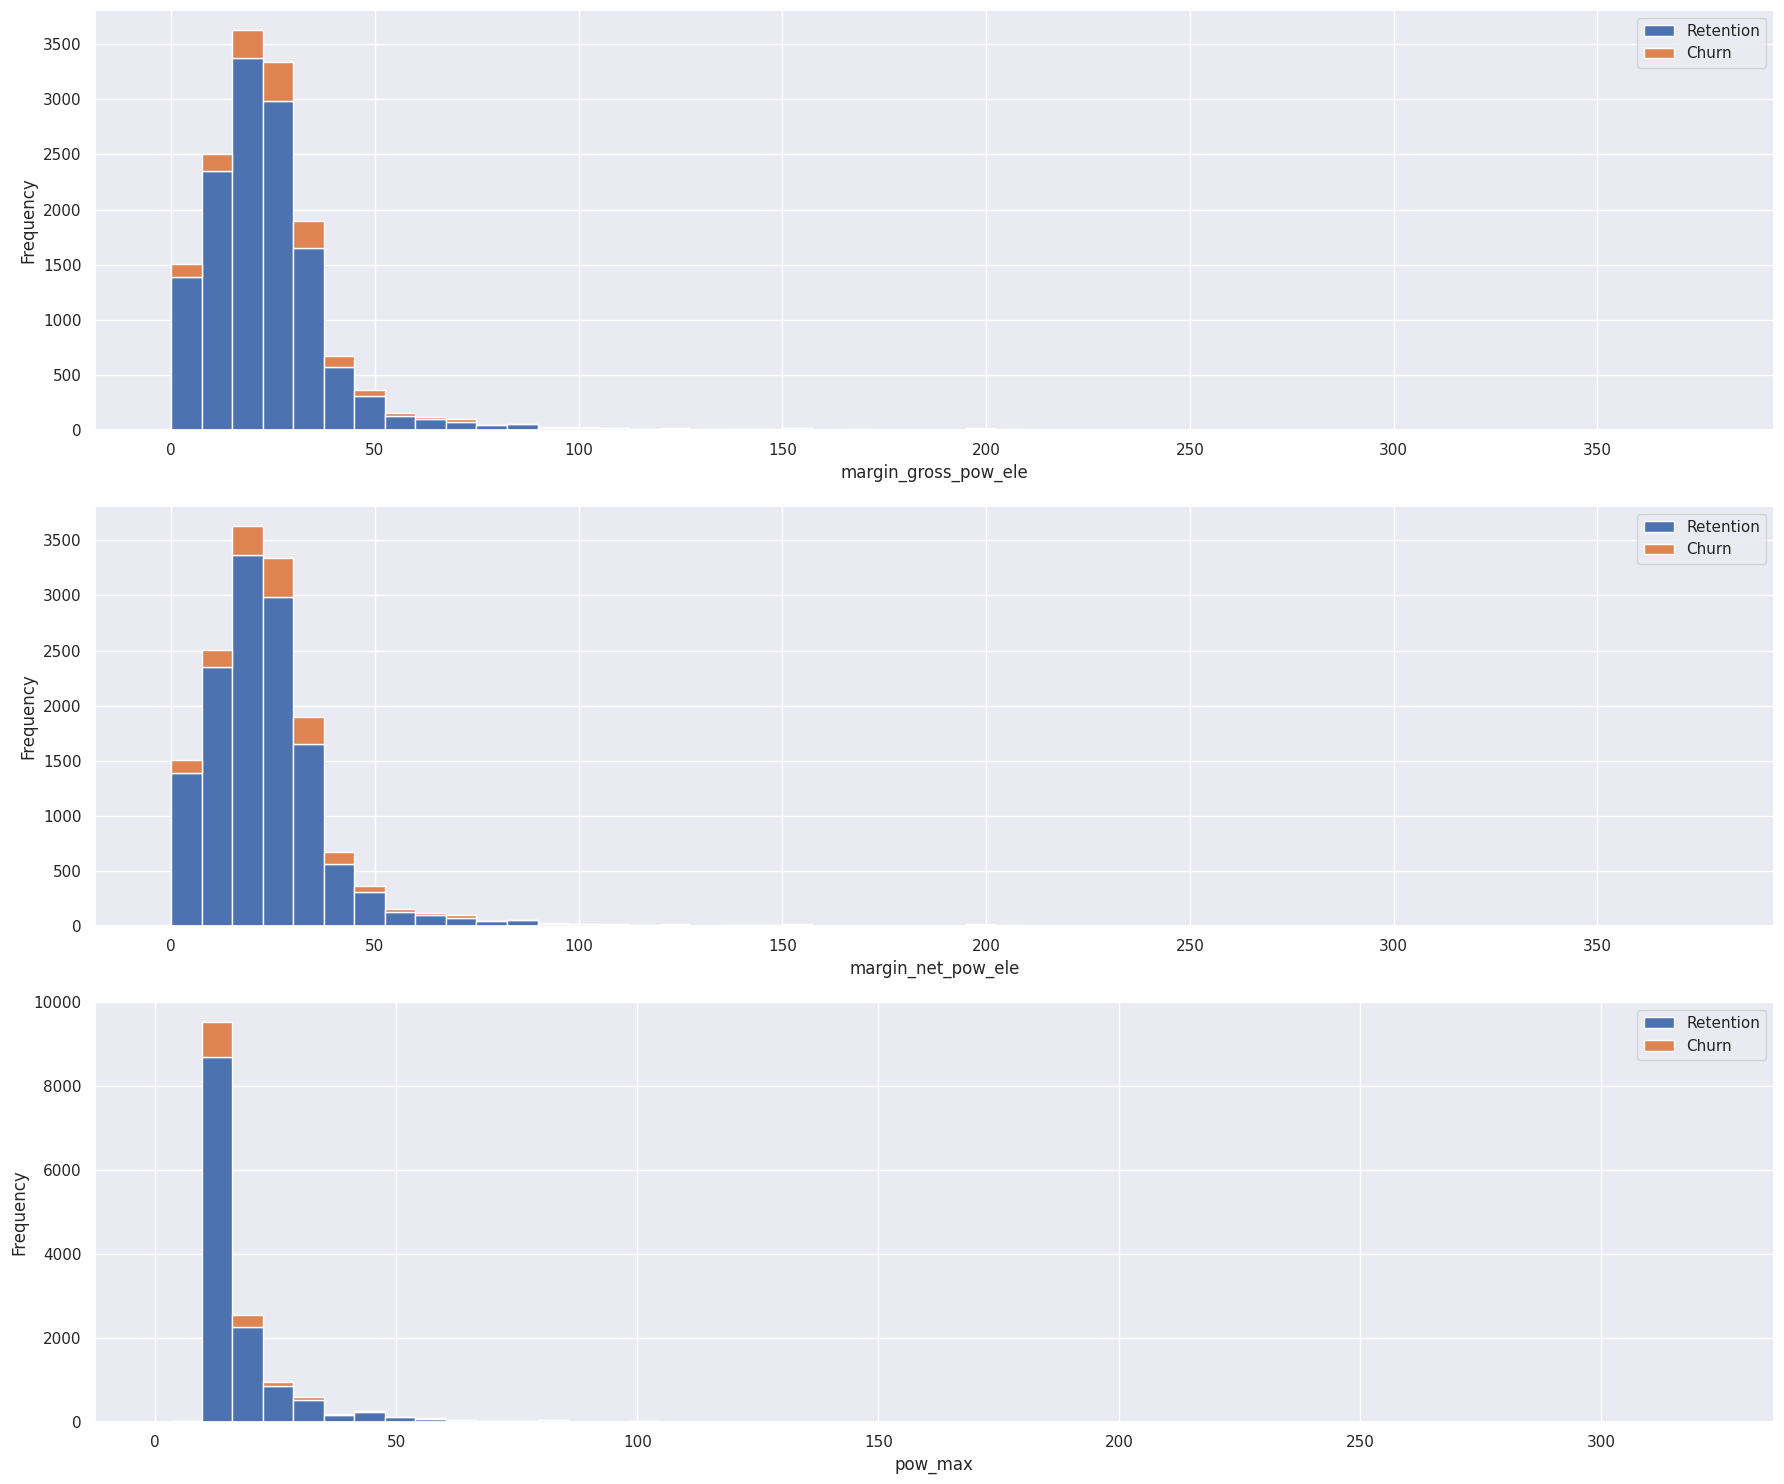

In [36]:
fig, axs = plt.subplots(nrows=3, figsize=(18, 15))
plot_distribution(client_df, 'margin_gross_pow_ele', axs[0])
plot_distribution(client_df, 'margin_net_pow_ele', axs[1])
plot_distribution(client_df, 'pow_max', axs[2])
plt.tight_layout()
plt.show()

### Antiquity (lama berlangganan) vs churn

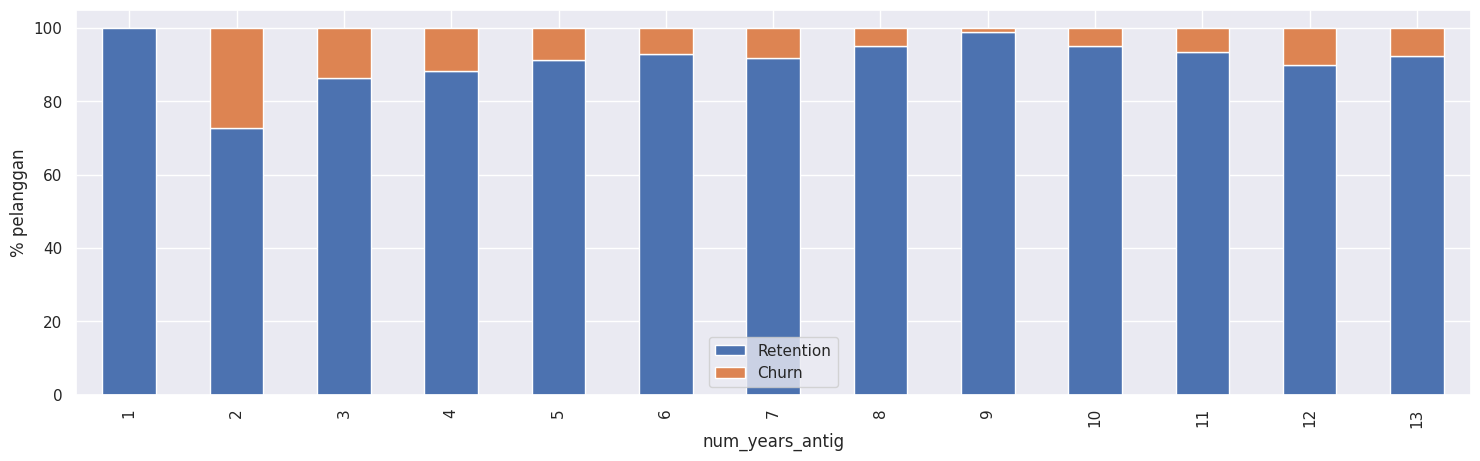

In [37]:
fig, axs = plt.subplots(nrows=1, figsize=(18, 5))
antiquity = client_df[['id', 'num_years_antig', 'churn']]
antiquity_churn = pd.crosstab(antiquity['num_years_antig'], antiquity['churn'])
antiquity_churn_pct = (antiquity_churn.div(antiquity_churn.sum(axis=1), axis=0) * 100)
antiquity_churn_pct.plot(kind='bar', stacked=True, ax=axs)
axs.set_ylabel('% pelanggan')
axs.legend(['Retention', 'Churn'])
plt.show()

### Kolom kategorikal vs churn (channel_sales, origin_up, has_gas)

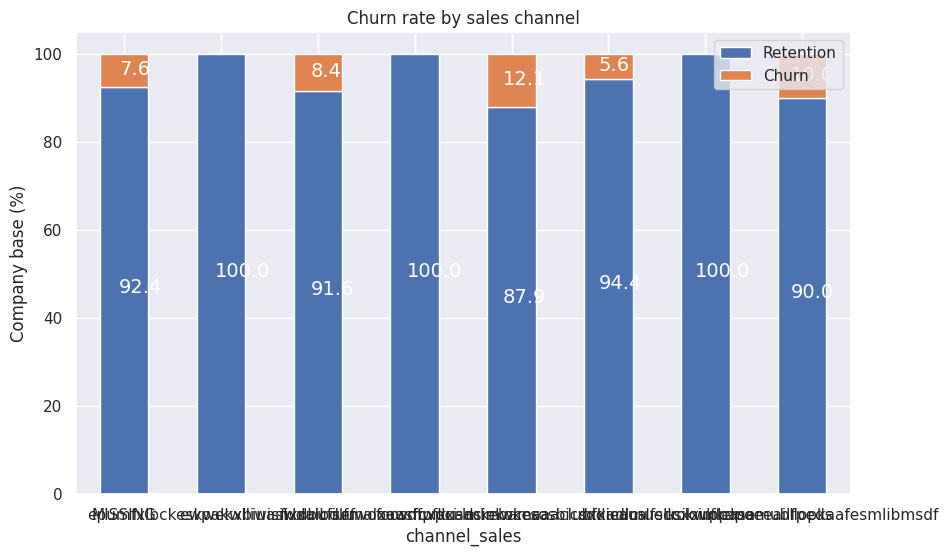

In [45]:
def plot_categorical_churn(df, column, title):
    ct = pd.crosstab(df[column], df['churn'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    plot_stacked_bars(ct_pct, title, size_=(10, 6))

plot_categorical_churn(client_df, 'channel_sales', 'Churn rate by sales channel')

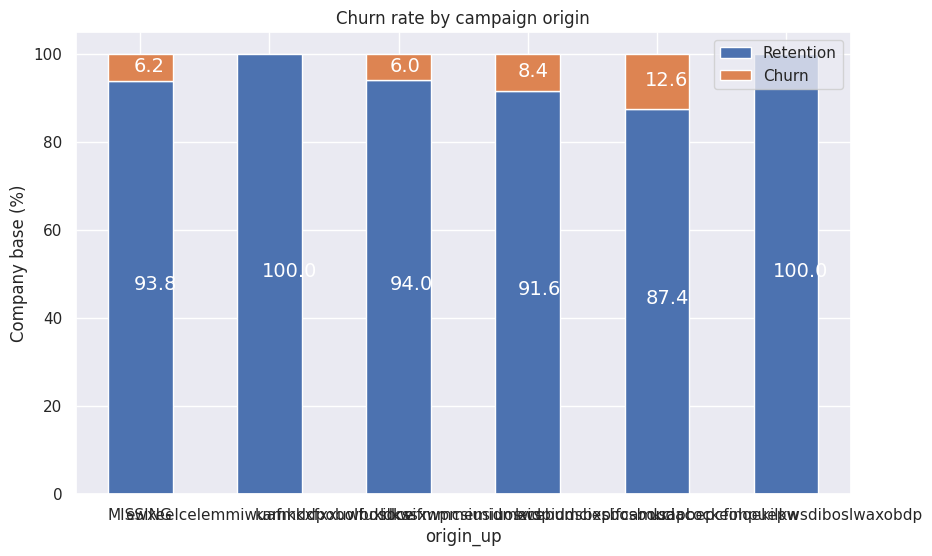

In [39]:
plot_categorical_churn(client_df, 'origin_up', 'Churn rate by campaign origin')

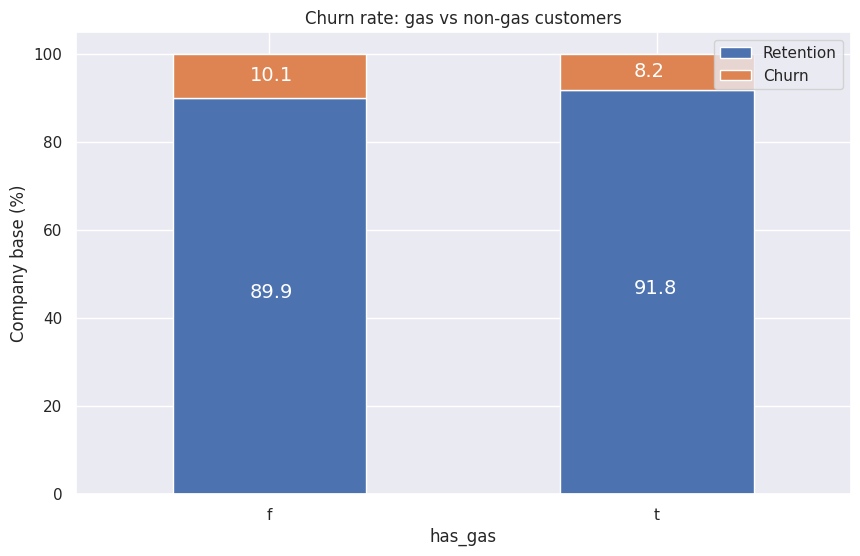

In [40]:
plot_categorical_churn(client_df, 'has_gas', 'Churn rate: gas vs non-gas customers')

**Insight:**

Terlihat variasi churn rate antar channel_sales dan origin_up, beberapa saluran penjualan/kampanye punya churn rate jauh lebih tinggi dari rata-rata (9.7%). Ini menunjukkan bahwa cara akuisisi pelanggan mungkin lebih berpengaruh terhadap churn dibanding harga semata.

### Menguji hipotesis: apakah harga (price sensitivity) berkaitan dengan churn?

Untuk menjawab hipotesis utama klien, kita bandingkan rata-rata harga yang dibayar pelanggan yang churn vs yang bertahan, menggunakan `price_data.csv`.

In [41]:
price_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
              'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

# Rata-rata harga per pelanggan sepanjang tahun 2015
avg_price = price_df.groupby('id')[price_cols].mean().reset_index()

# Gabungkan dengan status churn
price_churn = pd.merge(avg_price, client_df[['id', 'churn']], on='id', how='inner')

price_comparison = price_churn.groupby('churn')[price_cols].mean().T
price_comparison.columns = ['Retention (avg)', 'Churn (avg)']
price_comparison['Difference (%)'] = ((price_comparison['Churn (avg)'] - price_comparison['Retention (avg)'])
                                       / price_comparison['Retention (avg)'] * 100)
price_comparison

,Retention (avg),Churn (avg),Difference (%)
price_off_peak_var,0.142375,0.141887,-0.342810
price_peak_var,0.051579,0.056562,9.660799
price_mid_peak_var,0.027729,0.033355,20.290246
price_off_peak_fix,42.903812,43.161941,0.601646
price_peak_fix,9.274093,11.196663,20.730552
price_mid_peak_fix,5.983379,7.159896,19.663080


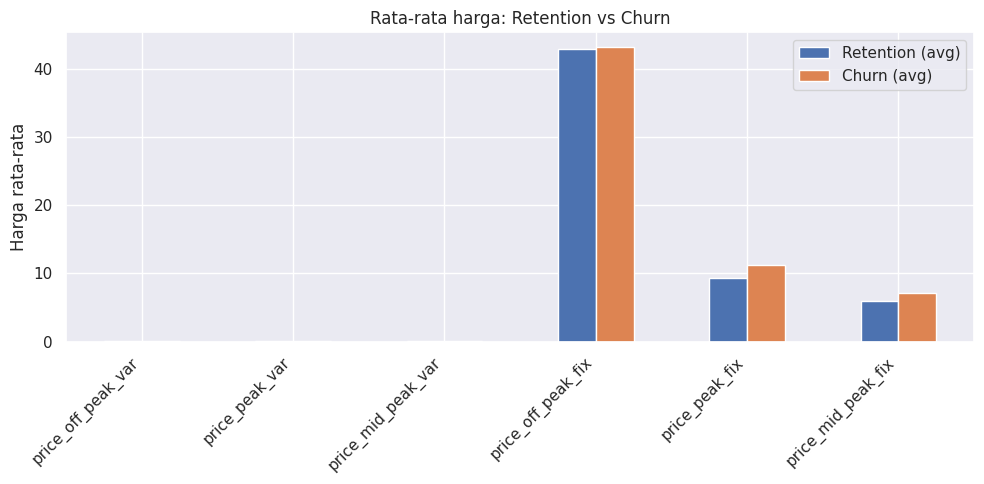

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
price_comparison[['Retention (avg)', 'Churn (avg)']].plot(kind='bar', ax=ax)
plt.title('Rata-rata harga: Retention vs Churn')
plt.ylabel('Harga rata-rata')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**

Rata-rata harga (baik variable (var) maupun fixed (fix)) antara pelanggan yang churn dan yang bertahan (retensi) **tidak jauh berbeda**, selisihnya relatif kecil dibanding sebaran (variasi) harga itu sendiri. **Ini adalah temuan penting** dimana harga absolut saja tampaknya bukan pembeda utama antara pelanggan yang churn dan yang tidak.

### Analisis lanjutan: perubahan harga (Desember vs Januari) - apakah kenaikan harga berkorelasi dengan churn?


In [46]:
price_df_sorted = price_df.sort_values(['id', 'price_date'])
first_last = price_df_sorted.groupby('id')[price_cols].agg(['first', 'last'])

price_change = pd.DataFrame({'id': first_last.index})
for col in price_cols:
    price_change[f'{col}_change'] = (first_last[(col, 'last')].values - first_last[(col, 'first')].values)

price_change_churn = pd.merge(price_change, client_df[['id', 'churn']], on='id', how='inner')
change_cols = [c for c in price_change_churn.columns if c.endswith('_change')]
price_change_churn.groupby('churn')[change_cols].mean().T

churn,0,1
price_off_peak_var_change,-0.004561,-0.004605
price_peak_var_change,-0.000812,-0.000960
price_mid_peak_var_change,0.000480,0.000484
price_off_peak_fix_change,0.277313,0.289483
price_peak_fix_change,-0.042336,-0.080595
price_mid_peak_fix_change,-0.024576,-0.037461


**Insight:**

Jika rata-rata perubahan harga sepanjang tahun antara kelompok `churn` dan `retention` juga berbeda tipis, ini **semakin memperkuat dugaan bahwa sensitivitas harga bukan faktor dominan**, kemungkinan ada faktor lain (channel akuisisi, layanan pelanggan, kontrak, dll.) yang lebih berperan. Hipotesis ini perlu dikonfirmasi lebih lanjut dengan feature engineering dan model prediktif pada tahap berikutnya.

### Korelasi antar variabel numerik dengan churn

In [48]:
import numpy as np

numeric_cols = client_df.select_dtypes(include=[np.number]).columns
corr = client_df[numeric_cols].corr()['churn'].sort_values(ascending=False)
corr

,churn
churn,1.000000
margin_net_pow_ele,0.095772
margin_gross_pow_ele,0.095725
forecast_meter_rent_12m,0.044245
net_margin,0.041135
pow_max,0.030362
forecast_price_energy_peak,0.029315
forecast_discount_energy,0.017026
forecast_price_pow_off_peak,0.014778
forecast_cons_12m,0.012949


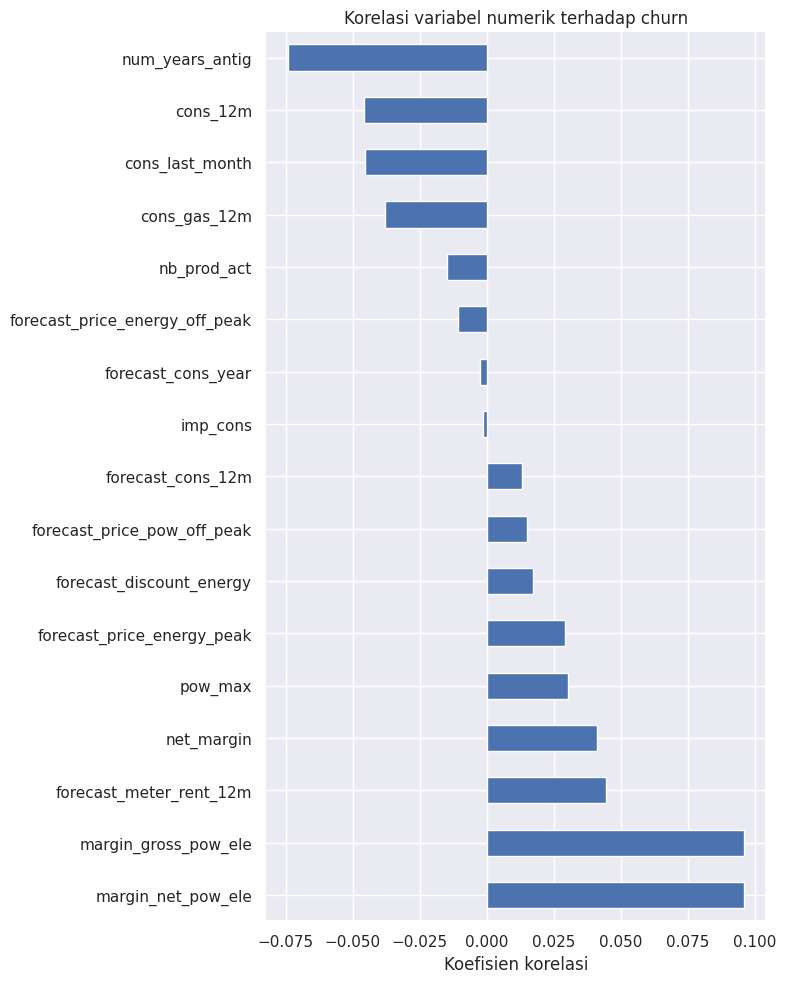

In [50]:
plt.figure(figsize=(8, 10))
corr.drop('churn').plot(kind='barh')
plt.title('Korelasi variabel numerik terhadap churn')
plt.xlabel('Koefisien korelasi')
plt.tight_layout()
plt.show()

**Insight:**

Korelasi linear semua variabel terhadap churn relatif lemah (mendekati 0). ini wajar untuk masalah churn karena hubungannya cenderung non-linear dan melibatkan interaksi antar variabel. Ini menjadi alasan kuat untuk menggunakan model non-linear (misalnya Random Forest / Gradient Boosting) pada tahap pemodelan berikutnya, bukan hanya korelasi sederhana.

## **Summary of Findings**

1. **Churn rate keseluruhan sekitar 9.7%**, terdapat dataset imbalanced sehingga perlu ditangani saat modeling.
2. **Distribusi konsumsi energi** sangat skewed (tidak simetris, condong ke salah satu sisi), tidak ada pola churn yang jelas berdasarkan level konsumsi.
3. **Channel penjualan (`channel_sales`) dan kampanye asal (`origin_up`)** menunjukkan variasi churn rate yang cukup besar antar kategori, hal ini  mengindikasikan bahwa faktor akuisisi pelanggan berperan.
4. **Rata-rata harga (variable & fixed) antara pelanggan churn dan retention tidak jauh berbeda**, begitu pula perubahan harga sepanjang tahun. Hal ini **melemahkan hipotesis awal klien (H1)** bahwa sensitivitas harga adalah penyebab utama terjadinya churn.
5. **Korelasi linear numerik terhadap churn yang lemah** menunjukkan hubungan bersifat non-linear/ kompleks, sehingga model prediktif diperlukan (bukan hanya statistika deskriptif) untuk menganalisis faktor apa saja yang benar-benar sebagai pendorong terjadinya churn.